# Лабораторна робота. Комп'ютерний практикум 1. 

---

## Задача 1, варіант 2 &nbsp;&nbsp; $y' = y^2 - x$

---

### Пункт 1–2. Поле напрямків та ізокліни

> **Означення 1: Ізокліна**  
> Крива $f(x, y) = \text{const}$ називається **ізокліною**. У точках ізоклін дотичні до всіх інтегральних кривих нахилені під однаковим кутом: $\alpha = \arctan(k)$.

Знайдемо рівняння ізоклін, прийнявши $y' = k$:
$$y^2 - x = k \implies x = y^2 - k$$
Це сімейство **парабол**, гілки яких спрямовані **вправо**, зміщених горизонтально на $-k$.

> **Означення 2: Поле напрямів**  
> Нехай через кожну точку $(x, y) \in D$ проведено одиничний відрізок з кутовим коефіцієнтом $\tan(\alpha) = f(x, y)$. Множина таких відрізків утворює **поле напрямів** диференціального рівняння.

Поле будуємо у вузлах сітки: $m \in \{-6, -5, \ldots, 6\}$, $n/2 \in \{-5, -4.5, \ldots, 5\}$.

---

### Пункт 3. Області зростання та спадання

- **Зростання** ($y' > 0$): &nbsp; $y^2 - x > 0 \implies x < y^2$ &nbsp; — область **ліворуч** від нуль-ізокліни.
- **Спадання** ($y' < 0$): &nbsp; $y^2 - x < 0 \implies x > y^2$ &nbsp; — область **праворуч** від нуль-ізокліни.

---

### Пункт 4. Точки максимуму та мінімуму розв'язків

Критичні точки: $y' = 0 \implies x = y^2$.  
Знайдемо другу похідну:
$$y'' = \frac{d}{dx}(y^2 - x) = 2y \cdot y' - 1$$
У критичних точках $y' = 0$, тому:
$$y''\big|_{y'=0} = 2y \cdot 0 - 1 = -1 < 0$$

Оскільки $y'' = -1 < 0$ для **всіх** критичних точок, кожна з них є точкою **локального максимуму**.

> **Висновок:** Множина точок максимуму — парабола $\boxed{x = y^2}$. Точок мінімуму немає ($\emptyset$).

---

### Пункти 5–6. Опуклість та точки перегину

Загальний вигляд другої похідної:
$$y'' = 2y(y^2 - x) - 1$$

- **Опуклість вгору** ($\cap$): $y'' < 0 \implies 2y(y^2 - x) - 1 < 0$
- **Опуклість вниз** ($\cup$): $y'' > 0 \implies 2y(y^2 - x) - 1 > 0$
- **Точки перегину** ($y'' = 0$):
$$2y(y^2 - x) - 1 = 0 \implies \boxed{x = y^2 - \frac{1}{2y}}, \quad y \neq 0$$

---

### Пункт 7. Інтегральні криві через задані точки

> **Означення 3: Задача Коші**  
> Знайти розв'язок $y(x)$, що задовольняє $y(x_0) = y_0$. Його графік — **інтегральна крива**, яка в кожній своїй точці дотична до поля напрямів.

Будуємо числовим методом (`solve_ivp`) інтегральні криві через точки:
- $(0,\; -2)$
- $(0,\; 0)$  
- $(0,\; 1)$

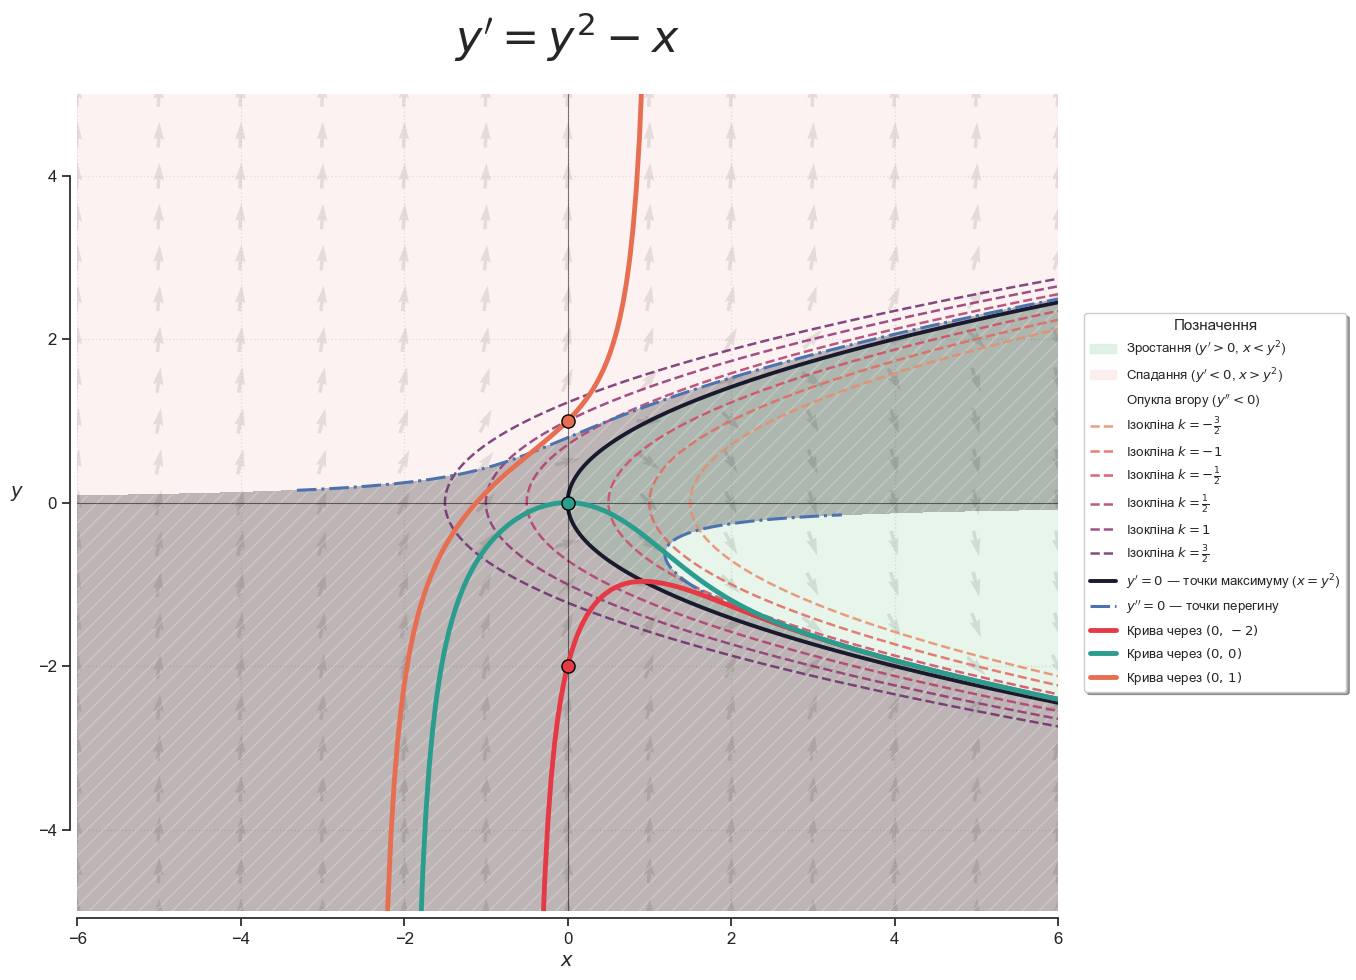

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.integrate import solve_ivp

# ─────────────────────────────────────────────
#  Загальне оформлення
# ─────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
sns.set_style("ticks", {"axes.grid": True, "grid.linestyle": ":"})

fig, ax = plt.subplots(figsize=(13, 10))

ax.set_xlim([-6, 6])
ax.set_ylim([-5, 5])
ax.set_xlabel('$x$', fontsize=14, fontweight='bold')
ax.set_ylabel('$y$', fontsize=14, fontweight='bold', rotation=0, labelpad=15)
ax.set_title(r"$y' = y^2 - x$", fontsize=32, fontweight='bold', pad=30)
ax.set_aspect('equal', adjustable='box')

# ─────────────────────────────────────────────
#  1. ПОЛЕ НАПРЯМКІВ
#     Сітка: m = -6..6 (крок 1), n/2 = -5..5 (крок 0.5)
# ─────────────────────────────────────────────
x_grid = np.arange(-6, 7, 1)
y_grid = np.arange(-10, 11, 1) / 2.0        # n/2, n = -10..10

X, Y = np.meshgrid(x_grid, y_grid)

U = np.ones_like(X)                          # dx = 1
V = Y**2 - X                                 # dy = f(x,y)
norm = np.sqrt(U**2 + V**2)

ax.quiver(X, Y, U / norm, V / norm,
          color='#8c8c8c', alpha=0.45,
          pivot='mid', scale=38, headwidth=3)

# ─────────────────────────────────────────────
#  Допоміжна сітка для contourf / contour
# ─────────────────────────────────────────────
xx = np.linspace(-6.5, 6.5, 600)
yy = np.linspace(-5.5, 5.5, 600)
XX, YY = np.meshgrid(xx, yy)

F   = YY**2 - XX                             # y'  = f(x, y)
F2  = 2 * YY * (YY**2 - XX) - 1             # y'' = 2y·f - 1

# ─────────────────────────────────────────────
#  2. ІЗОКЛІНИ  k = ±½, ±1, ±3/2
#     x = y² - k  →  параболи, зміщені горизонтально
# ─────────────────────────────────────────────
k_values  = [-1.5, -1.0, -0.5, 0.5, 1.0, 1.5]
k_labels  = [r'$k = -\frac{3}{2}$', r'$k = -1$', r'$k = -\frac{1}{2}$',
             r'$k = \frac{1}{2}$',   r'$k = 1$',  r'$k = \frac{3}{2}$']
iso_colors = sns.color_palette('flare', n_colors=len(k_values))

y_iso = np.linspace(-5.5, 5.5, 500)

for k, label, c in zip(k_values, k_labels, iso_colors):
    x_iso = y_iso**2 - k
    mask  = (x_iso >= -6.5) & (x_iso <= 6.5)
    ax.plot(x_iso[mask], y_iso[mask],
            '--', color=c, alpha=0.85, lw=1.8, label=f'Ізокліна {label}')

# ─────────────────────────────────────────────
#  3. ОБЛАСТІ ЗРОСТАННЯ ТА СПАДАННЯ
#     зростання (y'>0): x < y²  — ліворуч від параболи
#     спадання  (y'<0): x > y²  — праворуч від параболи
# ─────────────────────────────────────────────
ax.contourf(XX, YY, F,
            levels=[-1000, 0, 1000],
            colors=['#d4edda', '#fde8e8'],   # зелений / червоний
            alpha=0.55)

# ─────────────────────────────────────────────
#  4. НУЛЬ-ІЗОКЛІНА = КРИВА МАКСИМУМІВ
#     x = y²  (парабола, гілки вправо)
# ─────────────────────────────────────────────
x_null = y_iso**2
mask_null = (x_null >= -6.5) & (x_null <= 6.5)
ax.plot(x_null[mask_null], y_iso[mask_null],
        color='#1a1a2e', lw=2.8, label=r"$y'=0$ — точки максимуму ($x = y^2$)")

# ─────────────────────────────────────────────
#  5. ШТРИХУВАННЯ ОБЛАСТЕЙ ОПУКЛОСТІ
#     y'' < 0 → опукла вгору (∩) — штрихуємо
# ─────────────────────────────────────────────
ax.contourf(XX, YY, F2,
            levels=[-1000, 0],
            hatches=['//'],
            colors='none',
            alpha=0.25)

# ─────────────────────────────────────────────
#  6. КРИВА ТОЧОК ПЕРЕГИНУ
#     x = y² - 1/(2y),  y ≠ 0
# ─────────────────────────────────────────────
y_infl_pos = np.linspace( 0.15, 5.5, 400)
y_infl_neg = np.linspace(-5.5, -0.15, 400)

for y_seg in [y_infl_pos, y_infl_neg]:
    x_seg = y_seg**2 - 1.0 / (2 * y_seg)
    mask  = (x_seg >= -6.5) & (x_seg <= 6.5)
    ax.plot(x_seg[mask], y_seg[mask],
            color='#4c72b0', lw=2.2, ls='-.',
            label=r"$y''=0$ — точки перегину" if np.all(y_seg > 0) else "_nolegend_")

# ─────────────────────────────────────────────
#  7. ІНТЕГРАЛЬНІ КРИВІ через (0, -2), (0, 0), (0, 1)
#     Метод: RK45 (solve_ivp), ліво + право від x=0
# ─────────────────────────────────────────────
def ode(t, y):
    """Право частина: y' = y² - x"""
    return [y[0]**2 - t]

def stop_event(t, y):
    """Зупинка, якщо |y| виходить за межі графіка"""
    return 5.5 - abs(y[0])
stop_event.terminal  = True
stop_event.direction = -1

initial_points = [-2, 0, 1]
curve_colors   = ['#e63946', '#2a9d8f', '#e76f51']   # червоний, зелений, помаранчевий
curve_labels   = ['$(0,\,-2)$', '$(0,\,0)$', '$(0,\,1)$']

for y0, col, lbl in zip(initial_points, curve_colors, curve_labels):
    # Інтегруємо вправо  (x: 0 → +6.5)
    sol_r = solve_ivp(ode, (0,  6.5), [y0],
                      dense_output=True, events=stop_event, max_step=0.04)
    # Інтегруємо вліво   (x: 0 → -6.5)
    sol_l = solve_ivp(ode, (0, -6.5), [y0],
                      dense_output=True, events=stop_event, max_step=0.04)

    # Об'єднуємо: ліво (реверс) + право
    t_full = np.concatenate((sol_l.t[::-1], sol_r.t[1:]))
    y_full = np.concatenate((sol_l.y[0][::-1], sol_r.y[0][1:]))

    ax.plot(t_full, y_full,
            color=col, lw=3.5, zorder=4,
            label=f'Крива через {lbl}')
    ax.scatter(0, y0,
               color=col, edgecolors='black', s=90, zorder=5)

# ─────────────────────────────────────────────
#  Осі координат
# ─────────────────────────────────────────────
ax.axhline(0, color='black', lw=0.8, alpha=0.5)
ax.axvline(0, color='black', lw=0.8, alpha=0.5)

# ─────────────────────────────────────────────
#  Легенда та оформлення
# ─────────────────────────────────────────────
# Додаємо патчі для областей
patch_grow  = mpatches.Patch(color='#d4edda', alpha=0.7, label=r"Зростання ($y' > 0$, $x < y^2$)")
patch_dec   = mpatches.Patch(color='#fde8e8', alpha=0.7, label=r"Спадання ($y' < 0$, $x > y^2$)")
patch_conv  = mpatches.Patch(facecolor='white', hatch='//', alpha=0.6, label=r"Опукла вгору ($y'' < 0$)")

handles, labels = ax.get_legend_handles_labels()
handles = [patch_grow, patch_dec, patch_conv] + handles
labels  = [patch_grow.get_label(), patch_dec.get_label(), patch_conv.get_label()] + labels

ax.legend(handles, labels,
          loc='center left', bbox_to_anchor=(1.02, 0.5),
          frameon=True, shadow=True,
          title='Позначення', title_fontsize=11,
          fontsize=9.5)

sns.despine(trim=True, offset=5)
plt.tight_layout()
plt.savefig('Poshtak_lab_1_1.png', dpi=150, bbox_inches='tight')
plt.show()